# Volatility Project 01 · Data and Joins

*a compact first-hour workflow for turning unfamiliar financial tables into one point-in-time modeling table*

## The question

In a four-to-six-hour research exercise, the first deliverable is not a model. It is a table whose rows mean one thing, whose joins preserve that meaning, and whose features were genuinely available when the prediction would have been made. This notebook creates a historical panel, a future test panel, and three supporting finance-shaped tables, then demonstrates the join contracts that cover most panel tasks:

- **one-to-one:** attach one label to one `(date, asset)` observation;
- **many-to-one:** attach one static security record to many panel observations;
- **backward as-of:** attach the most recently released macro observation without reaching into the future.

The generated data deliberately contains a corrected duplicate label, missing volume, future-dated test rows with no target, and dates before the first macro release. Those are logged and handled explicitly so the clean-looking result does not conceal how it was produced.

The handoff is `train`, `test`, and `sample_submission`: one row per `(date, asset)`, source order preserved, no future macro timestamps, an explicit feature-availability table, and an issue log suitable for the top of an interview notebook.

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")
print(f"Python {platform.python_version()} | pandas {pd.__version__} | sklearn {sklearn.__version__}")

Python 3.12.0 | pandas 2.3.3 | sklearn 1.8.0


## Parameters

In [2]:
USE_DEMO = True
SEED = 42
N_ASSETS = 12
N_DATES = 100
N_TEST_DATES = 5
START_DATE = "2024-01-02"
TIME_COL = "date"
ENTITY_COL = "asset"
GROUP_COL = "sector"
TARGET_COL = "target_return_1d"
ID_COLS = (TIME_COL, ENTITY_COL)
LABEL_HORIZON = 1
TARGET_HISTORY_AVAILABLE = False
TARGET_HORIZON_DAYS = LABEL_HORIZON
PREDICTION_CUTOFF = "after_close"
PREDICTION_HOUR_UTC = 17
MACRO_START = 10
MACRO_STEP = 10
MISSING_VOLUME_RATE = 0.02
DUPLICATE_LABEL_ROW = 37
KEYS = list(ID_COLS)
TARGET = TARGET_COL
SECTORS = ("Financials", "Industrials", "Technology", "Utilities")

## Where the data comes from

This is the only data-loading cell. With `USE_DEMO=True` it generates deterministic source tables with realistic panel grain, genuinely future-dated test rows, and release timestamps. For an interview, replace this cell with the supplied file loaders and set `USE_DEMO=False`; the explicit guard prevents a broken real path from silently becoming a demo run. Keep the five output names—`prices`, `test_prices`, `labels_raw`, `security_master`, and `macro_releases`—or update the contracts below deliberately.

In [3]:
if not USE_DEMO:
    raise RuntimeError(
        "USE_DEMO=False requires replacing the swap-data cell with the interview files; "
        "demo fallback is intentionally disabled.")

rng = np.random.default_rng(SEED)
all_dates = pd.bdate_range(START_DATE, periods=N_DATES + N_TEST_DATES, name=TIME_COL)
train_dates, test_dates = all_dates[:N_DATES], all_dates[N_DATES:]
assets = pd.Index([f"A{i:02d}" for i in range(N_ASSETS)], name=ENTITY_COL)
index = pd.MultiIndex.from_product([all_dates, assets]).to_frame(index=False)
market = rng.normal(0.0002, 0.009, size=len(all_dates))
beta = rng.uniform(0.75, 1.25, size=N_ASSETS)
returns = market[:, None] * beta + rng.normal(0.0, 0.012, size=(len(all_dates), N_ASSETS))
all_prices = index.assign(
    close=(100 * np.exp(np.cumsum(returns, axis=0))).ravel(),
    volume=rng.lognormal(12.0, 0.45, size=len(index)).round())
missing_rows = rng.choice(len(all_prices), max(1, int(len(all_prices) * MISSING_VOLUME_RATE)), replace=False)
all_prices.loc[missing_rows, "volume"] = np.nan
is_train = all_prices[TIME_COL].isin(train_dates)
prices = all_prices.loc[is_train].reset_index(drop=True)
test_prices = all_prices.loc[~is_train].reset_index(drop=True)

next_close = all_prices.groupby(ENTITY_COL, sort=False)["close"].shift(-TARGET_HORIZON_DAYS)
labels = all_prices.loc[is_train, KEYS].copy()
labels[TARGET] = (next_close / all_prices["close"] - 1).loc[is_train].to_numpy()
labels["label_version"] = 1
correction = labels.iloc[[DUPLICATE_LABEL_ROW]].copy().assign(label_version=2)
labels.loc[DUPLICATE_LABEL_ROW, TARGET] += 0.01
labels_raw = pd.concat([labels, correction], ignore_index=True)

security_master = pd.DataFrame({
    "asset": assets, "sector": np.resize(SECTORS, N_ASSETS),
    "exchange": np.where(np.arange(N_ASSETS) % 2, "XEUR", "XLON"),
    "market_cap": rng.lognormal(23.0, 0.7, size=N_ASSETS)})
release_dates = all_dates[MACRO_START::MACRO_STEP]
macro_releases = pd.DataFrame({"release_ts": release_dates + np.timedelta64(8, "h") + np.timedelta64(30, "m")})
macro_releases["macro_surprise"] = rng.normal(0.0, 1.0, len(macro_releases))
macro_releases["policy_rate"] = 0.03 + np.cumsum(rng.normal(0.0, 0.0005, len(macro_releases)))
assert TARGET not in test_prices.columns
assert prices[TIME_COL].max() < test_prices[TIME_COL].min()
assert not test_prices.duplicated(KEYS).any()

print("DEMO DATA — replace this cell before using interview files")
print({"prices": prices.shape, "test_prices": test_prices.shape,
       "labels_raw": labels_raw.shape, "security_master": security_master.shape,
       "macro_releases": macro_releases.shape})
prices.head(3)

DEMO DATA — replace this cell before using interview files
{'prices': (1200, 4), 'test_prices': (60, 4), 'labels_raw': (1201, 4), 'security_master': (12, 4), 'macro_releases': (10, 3)}


,date,asset,close,volume
0,2024-01-02,A00,100.287372,176269.0
1,2024-01-02,A01,102.180431,185545.0
2,2024-01-02,A02,100.066273,315882.0


## Recipes in this notebook

| Recipe | What it does |
|---|---|
| [R10.1](#r10-1) | Inventory every source at its declared grain |
| [R10.2](#r10-2) | Plot coverage and the future target before joining |
| [R10.3](#r10-3) | Resolve a corrected duplicate and start the issue log |
| [R10.4](#r10-4) | Join panel labels one-to-one |
| [R10.5](#r10-5) | Join static attributes many-to-one |
| [R10.6](#r10-6) | Join timestamped macro releases backward in time |
| [R10.7](#r10-7) | Separate features, metadata and future labels by availability |
| [R10.8](#r10-8) | Audit future drift, re-check integrity, and publish the issue log |

The notebook is deliberately linear. In an interview, finish this data contract before opening the modeling notebook; a fast model on a corrupted join is only a fast wrong answer.

## Things to watch

- State each table's grain before touching `merge`; column names alone do not establish uniqueness.
- Use `validate=` on every equality join. It turns fan-out into an exception instead of a quietly reweighted sample.
- Treat a corrected duplicate as a source-policy question. Here the highest declared version wins; on real data, confirm that rule with the data dictionary.
- Join event data on its release timestamp and the declared prediction timestamp. `direction="backward"` is the point-in-time contract.
- Missing macro values before the first release are honest missing values. Backfilling them would import future information.
- A future return is the label, never a feature. Write the prediction cutoff down before deciding whether same-day close or volume is allowed.

## R10.1 · Inventory every source at its declared grain
<a id="r10-1"></a>

**Topic** Data quality

**Use when** opening unfamiliar files. This table makes row counts, key uniqueness, missingness, memory and time coverage comparable before any merge changes them.

**Inputs** `prices`, future-dated `test_prices`, `labels_raw`, `security_master`, and `macro_releases` from the swap-data cell.

**Needs** nothing beyond the setup and data cells

**Gotchas** `duplicate_key_rows` counts every row involved in a duplicate, not the number of distinct duplicate keys. A nonzero value is a stop sign until a source policy resolves it.

**See also** [R10.3](#r10-3) (resolve the known duplicate) · [R10.8](#r10-8) (repeat checks after joining)

In [4]:
table_specs = [
    ("prices", prices, KEYS, "date"),
    ("test_prices", test_prices, KEYS, "date"),
    ("labels_raw", labels_raw, KEYS, "date"),
    ("security_master", security_master, ["asset"], None),
    ("macro_releases", macro_releases, ["release_ts"], "release_ts"),
]
rows = []
for name, frame, key, time_col in table_specs:
    rows.append({
        "table": name, "grain": " × ".join(key), "rows": len(frame),
        "columns": frame.shape[1],
        "duplicate_key_rows": int(frame.duplicated(key, keep=False).sum()),
        "missing_cells": int(frame.isna().sum().sum()),
        "memory_mb": frame.memory_usage(deep=True).sum() / 1e6,
        "time_min": frame[time_col].min() if time_col else pd.NaT,
        "time_max": frame[time_col].max() if time_col else pd.NaT,
    })
table_inventory = pd.DataFrame(rows).set_index("table")
display(table_inventory.round({"memory_mb": 3}))

,grain,rows,columns,duplicate_key_rows,missing_cells,memory_mb,time_min,time_max
table,,,,,,,,
prices,date × asset,1200,4,0,25,0.091,2024-01-02 00:00:00,2024-05-20 00:00:00
test_prices,date × asset,60,4,0,0,0.005,2024-05-21 00:00:00,2024-05-27 00:00:00
labels_raw,date × asset,1201,4,2,0,0.091,2024-01-02 00:00:00,2024-05-20 00:00:00
security_master,asset,12,4,0,0,0.002,NaT,NaT
macro_releases,release_ts,10,3,0,0,0.000,2024-01-16 08:30:00,2024-05-21 08:30:00


Types are part of the contract too. Show every parsed dtype, assert the few semantic types later operations rely on, and count numeric infinities separately from missing values.

In [5]:
source_frames = {"prices": prices, "test_prices": test_prices, "labels_raw": labels_raw,
                 "security_master": security_master, "macro_releases": macro_releases}
dtype_report = pd.concat(
    {name: frame.dtypes.astype(str) for name, frame in source_frames.items()},
    names=["table", "column"]).rename("dtype").to_frame()
dtype_checks = pd.DataFrame([
    ("prices.date is datetime", str(prices["date"].dtype), pd.api.types.is_datetime64_any_dtype(prices["date"])),
    ("prices.asset is string-like", str(prices["asset"].dtype), pd.api.types.is_string_dtype(prices["asset"])),
    ("prices.close is numeric", str(prices["close"].dtype), pd.api.types.is_numeric_dtype(prices["close"])),
    ("test target is absent", "absent" if TARGET not in test_prices else "present", TARGET not in test_prices),
    ("macro release_ts is datetime", str(macro_releases["release_ts"].dtype), pd.api.types.is_datetime64_any_dtype(macro_releases["release_ts"])),
    ("target is numeric", str(labels_raw[TARGET].dtype), pd.api.types.is_numeric_dtype(labels_raw[TARGET])),
], columns=["check", "actual_dtype", "passed"])
infinity_report = pd.DataFrame([
    {"table": name, "numeric_infinities": int(np.isinf(frame.select_dtypes(include=np.number).to_numpy()).sum())}
    for name, frame in source_frames.items()])
assert dtype_checks["passed"].all() and infinity_report["numeric_infinities"].sum() == 0
display(dtype_report)
display(dtype_checks)
display(infinity_report.set_index("table"))

dtype
table           column                          
prices          date              datetime64[ns]
                asset                     object
                close                    float64
                volume                   float64
test_prices     date              datetime64[ns]
                asset                     object
                close                    float64
                volume                   float64
labels_raw      date              datetime64[ns]
                asset                     object
                target_return_1d         float64
                label_version              int64
security_master asset                     object
                sector                    object
                exchange                  object
                market_cap               float64
macro_releases  release_ts        datetime64[ns]
                macro_surprise           float64
                policy_rate              float64

,check,actual_dtype,passed
0,prices.date is datetime,datetime64[ns],True
1,prices.asset is string-like,object,True
2,prices.close is numeric,float64,True
3,test target is absent,absent,True
4,macro release_ts is datetime,datetime64[ns],True
5,target is numeric,float64,True


,numeric_infinities
table,
prices,0
test_prices,0
labels_raw,0
security_master,0
macro_releases,0


## R10.2 · Plot coverage and the future target before joining
<a id="r10-2"></a>

**Topic** Exploratory analysis

**Use when** checking whether the panel is balanced, whether the future-return label has difficult tails, and whether its center shifts through time.

**Inputs** `prices`, `labels_raw`, `KEYS`, and `TARGET` from the data and parameters cells.

**Needs** nothing beyond the setup and data cells

**Gotchas** Resolve versions by the declared label policy before plotting. Including both the original and corrected record double-weights exactly the observation already known to be problematic.

**See also** [R10.1](#r10-1) (source inventory) · [R10.8](#r10-8) (post-join health)

,count,mean,std,min,max
period,,,,,
early,600,0.0006,0.0138,-0.0391,0.0561
late,600,-0.0017,0.0134,-0.0441,0.0382


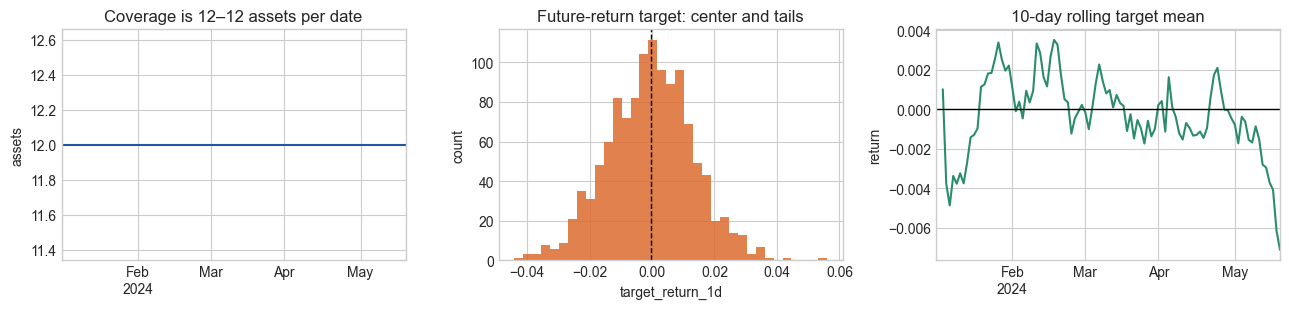

In [6]:
target_preview = (labels_raw.sort_values(KEYS + ["label_version"])
                  .drop_duplicates(KEYS, keep="last").dropna(subset=[TARGET]))
coverage = prices.groupby("date")["asset"].nunique()
daily_target = target_preview.groupby("date")[TARGET].agg(["mean", "std"])
midpoint = target_preview["date"].drop_duplicates().sort_values().iloc[N_DATES // 2]
target_stability = (target_preview.assign(period=np.where(target_preview["date"] < midpoint, "early", "late"))
                    .groupby("period")[TARGET].agg(["count", "mean", "std", "min", "max"]))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
coverage.plot(ax=axes[0], color="#2455a4")
axes[0].set(title=f"Coverage is {coverage.min()}–{coverage.max()} assets per date", ylabel="assets")
axes[0].set_xlabel("")
axes[1].hist(target_preview[TARGET], bins=35, color="#db6b2f", alpha=0.85)
axes[1].axvline(target_preview[TARGET].median(), color="black", linestyle="--", linewidth=1)
axes[1].set(title="Future-return target: center and tails", xlabel=TARGET, ylabel="count")
daily_target["mean"].rolling(10, min_periods=3).mean().plot(ax=axes[2], color="#2a8c6d")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set(title="10-day rolling target mean", ylabel="return", xlabel="")
fig.tight_layout()
display(target_stability.round(4))

## R10.3 · Resolve a corrected duplicate and start the issue log
<a id="r10-3"></a>

**Topic** Data quality

**Use when** a feed publishes corrected records under the same business key. Preserve the evidence, state the version policy, then assert that the resolved table is unique.

**Inputs** `labels_raw`, `KEYS`, and `TARGET` from the data and parameters cells.

**Needs** R10.1

**Gotchas** `drop_duplicates(keep="last")` is only meaningful after an explicit sort by the authoritative version or update timestamp. Filesystem order is not a correction policy.

**See also** [R10.4](#r10-4) (contracted label join) · [R10.8](#r10-8) (final issue log)

In [7]:
duplicate_mask = labels_raw.duplicated(KEYS, keep=False)
duplicate_labels = labels_raw.loc[duplicate_mask].sort_values(KEYS + ["label_version"])
labels_clean = (labels_raw.sort_values(KEYS + ["label_version"])
                .drop_duplicates(KEYS, keep="last")
                .sort_values(KEYS).reset_index(drop=True))
assert not labels_clean.duplicated(KEYS).any()
resolved_keys = int(duplicate_labels[KEYS].drop_duplicates().shape[0])
issue_log = pd.DataFrame([{
    "severity": "error",
    "check": "label key uniqueness",
    "evidence": f"{resolved_keys} corrected key; {duplicate_mask.sum()} source rows",
    "action": "kept highest label_version after declaring the source policy",
    "status": "resolved",
}])
display(duplicate_labels)
display(issue_log)

,date,asset,target_return_1d,label_version
37,2024-01-05,A01,0.007326,1
1200,2024-01-05,A01,-0.002674,2


,severity,check,evidence,action,status
0,error,label key uniqueness,1 corrected key; 2 source rows,kept highest label_version after declaring the...,resolved


## R10.4 · Join panel labels one-to-one
<a id="r10-4"></a>

**Topic** Joins

**Use when** each observation may have at most one label at the same panel key. `validate="one_to_one"` protects both sides of the contract.

**Inputs** `prices`, `labels_clean`, `KEYS`, and `TARGET`.

**Needs** R10.3

**Gotchas** A matched key can still carry a missing target, so inspect both the merge indicator and target nulls. The separate future test panel deliberately has no target and never enters this join.

**See also** [R10.5](#r10-5) (many-to-one attributes) · [R10.7](#r10-7) (label availability)

In [8]:
panel_labeled = prices.merge(
    labels_clean, on=KEYS, how="left", validate="one_to_one", indicator=True)
join_1to1 = pd.Series({
    "left_rows": len(prices),
    "joined_rows": len(panel_labeled),
    "row_delta": len(panel_labeled) - len(prices),
    "matched": int(panel_labeled["_merge"].eq("both").sum()),
    "missing_targets": int(panel_labeled[TARGET].isna().sum()),
}, name="one_to_one label join")
assert len(panel_labeled) == len(prices)
assert panel_labeled["_merge"].eq("both").all()
panel_labeled = panel_labeled.drop(columns="_merge")
display(join_1to1.to_frame("value"))

,value
left_rows,1200
joined_rows,1200
row_delta,0
matched,1200
missing_targets,0


## R10.5 · Join static attributes many-to-one
<a id="r10-5"></a>

**Topic** Joins

**Use when** many dated observations map to one stable security record. The right table must be unique on `asset`; a duplicate master row must raise instead of multiplying the panel.

**Inputs** `panel_labeled`, future `test_prices`, and `security_master`.

**Needs** R10.4

**Gotchas** Static does not mean timeless. If sector or listing status changes historically, use an interval or as-of join instead of pretending the latest master record always applied.

**See also** [R10.6](#r10-6) (time-varying attributes) · [R10.8](#r10-8) (row-count reconciliation)

In [9]:
assert not security_master.duplicated("asset").any()
panel_static = panel_labeled.merge(
    security_master, on="asset", how="left", validate="many_to_one", indicator=True)
join_many_to_one = pd.Series({
    "left_rows": len(panel_labeled),
    "joined_rows": len(panel_static),
    "row_delta": len(panel_static) - len(panel_labeled),
    "unmatched_assets": int(panel_static.loc[panel_static["_merge"].ne("both"), "asset"].nunique()),
}, name="many_to_one master join")
assert len(panel_static) == len(panel_labeled)
assert panel_static["_merge"].eq("both").all()
panel_static = panel_static.drop(columns="_merge")
test_static = test_prices.merge(
    security_master, on=ENTITY_COL, how="left", validate="many_to_one")
assert len(test_static) == len(test_prices) and test_static[GROUP_COL].notna().all()
display(join_many_to_one.to_frame("value"))

,value
left_rows,1200
joined_rows,1200
row_delta,0
unmatched_assets,0


## R10.6 · Join timestamped macro releases backward in time
<a id="r10-6"></a>

**Topic** As-of joins

**Use when** an event feature is released irregularly and remains in force until the next release. Each panel row receives the latest macro record published by its declared prediction timestamp.

**Inputs** historical `panel_static`, future `test_static`, `macro_releases`, and `PREDICTION_HOUR_UTC`.

**Needs** R10.5

**Gotchas** Compare full timestamps, not normalized dates, and sort both frames on the as-of key. A forward join or backward-filling early missing values leaks a release that was not yet public.

**See also** [R10.7](#r10-7) (availability contract) · [R10.8](#r10-8) (assert no future matches)

In [10]:
right = macro_releases.sort_values("release_ts")
def attach_latest_macro(frame):
    left = frame.assign(
        prediction_ts=frame[TIME_COL] + np.timedelta64(PREDICTION_HOUR_UTC, "h"),
        _source_order=np.arange(len(frame))).sort_values("prediction_ts")
    out = pd.merge_asof(
        left, right, left_on="prediction_ts", right_on="release_ts",
        direction="backward", allow_exact_matches=True)
    future = out["release_ts"].notna() & out["release_ts"].gt(out["prediction_ts"])
    assert len(out) == len(frame) and not future.any()
    return out.sort_values("_source_order").drop(columns="_source_order").reset_index(drop=True)

joined = attach_latest_macro(panel_static)
test_joined = attach_latest_macro(test_static)
asof_summary = pd.DataFrame({name: {
    "left_rows": len(frame), "joined_rows": len(result),
    "rows_with_macro": int(result["release_ts"].notna().sum()),
    "rows_before_first_release": int(result["release_ts"].isna().sum()),
    "future_matches": int((result["release_ts"] > result["prediction_ts"]).fillna(False).sum()),
} for name, frame, result in [("train", panel_static, joined), ("test", test_static, test_joined)]}).T
display(asof_summary)
joined.loc[joined["release_ts"].notna(),
           ["date", "prediction_ts", "release_ts", "asset", "macro_surprise", "policy_rate"]].head(3)

,left_rows,joined_rows,rows_with_macro,rows_before_first_release,future_matches
train,1200,1200,1080,120,0
test,60,60,60,0,0


,date,prediction_ts,release_ts,asset,macro_surprise,policy_rate
120,2024-01-16,2024-01-16 17:00:00,2024-01-16 08:30:00,A00,0.485198,0.029655
121,2024-01-16,2024-01-16 17:00:00,2024-01-16 08:30:00,A01,0.485198,0.029655
122,2024-01-16,2024-01-16 17:00:00,2024-01-16 08:30:00,A02,0.485198,0.029655


## R10.7 · Separate features, metadata and future labels by availability
<a id="r10-7"></a>

**Topic** Leakage

**Use when** converting a joined data frame into a modeling contract. Every column gets a role, an availability rule, and an explicit decision before feature selection.

**Inputs** historical `joined`, future `test_joined`, `TARGET`, and `PREDICTION_CUTOFF`.

**Needs** R10.6

**Gotchas** Same-day close and volume are only valid because this exercise declares an after-close cutoff. Move the prediction earlier and those rows in the table must change to unavailable.

**See also** [R10.4](#r10-4) (future label) · [R10.8](#r10-8) (final assertions)

In [11]:
availability = pd.DataFrame([
    ("date", "identifier", "row timestamp", False),
    ("asset", "identifier", "before prediction", False),
    ("close", "feature", PREDICTION_CUTOFF, PREDICTION_CUTOFF == "after_close"),
    ("volume", "feature", PREDICTION_CUTOFF, PREDICTION_CUTOFF == "after_close"),
    ("sector", "feature", "static master known before prediction", True),
    ("exchange", "feature", "static master known before prediction", True),
    ("market_cap", "feature", "static master known before prediction", True),
    ("macro_surprise", "feature", "latest release_ts <= prediction_ts", True),
    ("policy_rate", "feature", "latest release_ts <= prediction_ts", True),
    ("prediction_ts", "metadata", "declared scoring cutoff", False),
    ("release_ts", "metadata", "macro publication timestamp", False),
    (TARGET, "target", "future label; target history unavailable as a feature", False),
    ("label_version", "metadata", "label correction feed", False),
], columns=["column", "role", "available_when", "allowed_as_feature"])
model_features = availability.query("role == 'feature' and allowed_as_feature")["column"].tolist()
assert TARGET not in model_features and set(model_features).issubset(joined.columns)
train = joined.copy()
test = test_joined.copy()
sample_submission = test[KEYS].copy()
sample_submission[TARGET] = 0.0
assert TARGET in train and TARGET not in test and train[TIME_COL].max() < test[TIME_COL].min() and not train.duplicated(KEYS).any() and not test.duplicated(KEYS).any()
assert test[KEYS].equals(sample_submission[KEYS])
display(availability)
{"model_features": model_features, "train": train.shape, "test": test.shape, "sample_submission": sample_submission.shape}

,column,role,available_when,allowed_as_feature
0,date,identifier,row timestamp,False
1,asset,identifier,before prediction,False
2,close,feature,after_close,True
3,volume,feature,after_close,True
4,sector,feature,static master known before prediction,True
5,exchange,feature,static master known before prediction,True
6,market_cap,feature,static master known before prediction,True
7,macro_surprise,feature,latest release_ts <= prediction_ts,True
8,policy_rate,feature,latest release_ts <= prediction_ts,True
9,prediction_ts,metadata,declared scoring cutoff,False


{'model_features': ['close',
  'volume',
  'sector',
  'exchange',
  'market_cap',
  'macro_surprise',
  'policy_rate'],
 'train': (1200, 13),
 'test': (60, 11),
 'sample_submission': (60, 3)}

## R10.8 · Audit future drift, re-check integrity, and publish the issue log
<a id="r10-8"></a>

**Topic** Health check

**Use when** handing the modeling table to cross-validation. Seal a future block, inspect drift, repeat all join invariants, and distinguish errors from accepted structural missingness.

**Inputs** `train`, future `test`, `sample_submission`, `issue_log`, `model_features`, `KEYS`, and `TARGET`.

**Needs** R10.7

**Gotchas** Drift is a warning, not automatic proof of a bad column. Do not fill missing features here using the full data; imputation is fitted inside each training fold.

**See also** [R10.1](#r10-1) (before-join inventory) · [R10.6](#r10-6) (point-in-time join)

Reserve the last 20% of whole dates as a future diagnostic block. Standardized mean change and missingness change are deliberately simple: they are fast to explain and point directly to the columns worth plotting next.

In [12]:
unique_dates = np.sort(joined["date"].unique())
future_start = pd.Timestamp(unique_dates[int(0.80 * len(unique_dates))])
train_view = joined.loc[joined["date"] < future_start]
future_view = joined.loc[joined["date"] >= future_start]
drift_numeric = joined[model_features].select_dtypes(include=np.number).columns.tolist()
train_scale = train_view[drift_numeric].std().replace(0, np.nan)
drift_view = pd.DataFrame({
    "train_mean": train_view[drift_numeric].mean(),
    "future_mean": future_view[drift_numeric].mean(),
    "standardized_mean_delta": (future_view[drift_numeric].mean() - train_view[drift_numeric].mean()) / train_scale,
    "train_missing_rate": train_view[drift_numeric].isna().mean(),
    "future_missing_rate": future_view[drift_numeric].isna().mean(),
})
drift_view["missing_rate_delta"] = drift_view["future_missing_rate"] - drift_view["train_missing_rate"]
drift_view = drift_view.reindex(drift_view["standardized_mean_delta"].abs().sort_values(ascending=False).index)
print(f"future diagnostic block: {future_start.date()} onward · {len(future_view)} rows")
display(drift_view.round(4))

future diagnostic block: 2024-04-23 onward · 240 rows


,train_mean,future_mean,standardized_mean_delta,train_missing_rate,future_missing_rate,missing_rate_delta
policy_rate,2.860000e-02,2.680000e-02,-2.8090,0.1250,0.0000,-0.1250
macro_surprise,1.952000e-01,5.056000e-01,0.3291,0.1250,0.0000,-0.1250
close,1.012237e+02,9.974780e+01,-0.2663,0.0000,0.0000,0.0000
volume,1.747896e+05,1.837819e+05,0.1071,0.0188,0.0292,0.0104
market_cap,9.641921e+09,9.641921e+09,0.0000,0.0000,0.0000,0.0000


The drift view is descriptive. Finish with hard structural assertions across the historical training table and the genuinely future-dated test table, then expose the exact submission-order contract a downstream model must preserve.

In [13]:
combined_model = pd.concat([train, test], ignore_index=True, sort=False)
post_join_health = pd.Series({
    "train_rows": len(train),
    "test_rows": len(test),
    "sample_submission_rows": len(sample_submission),
    "duplicate_train_keys": int(train.duplicated(KEYS).sum()),
    "duplicate_test_keys": int(test.duplicated(KEYS).sum()),
    "missing_train_targets": int(train[TARGET].isna().sum()),
    "rows_without_macro": int(combined_model["release_ts"].isna().sum()),
    "future_macro_matches": int((combined_model["release_ts"] > combined_model["prediction_ts"]).fillna(False).sum()),
    "maximum_feature_null_rate": float(combined_model[model_features].isna().mean().max()),
}, name="post-join health")
assert len(train) == len(prices) and len(test) == len(test_prices) == len(sample_submission)
assert post_join_health[["duplicate_train_keys", "duplicate_test_keys", "future_macro_matches"]].eq(0).all()
additional_issues = pd.DataFrame([
    ("warning", "missing volume", f"{combined_model['volume'].isna().sum()} rows", "fit imputation inside each CV training fold", "open"),
    ("info", "pre-release macro values", f"{combined_model['release_ts'].isna().sum()} early rows", "keep missing; never backfill from a future release", "accepted"),
    ("info", "test target absence", f"{len(test)} future rows", "score these rows only; preserve sample-submission order", "accepted"),
], columns=["severity", "check", "evidence", "action", "status"])
final_issue_log = pd.concat([issue_log, additional_issues], ignore_index=True)
display(post_join_health.to_frame("value"))
display(final_issue_log)
sample_submission.head(3)

,value
train_rows,1200.000000
test_rows,60.000000
sample_submission_rows,60.000000
duplicate_train_keys,0.000000
duplicate_test_keys,0.000000
missing_train_targets,0.000000
rows_without_macro,120.000000
future_macro_matches,0.000000
maximum_feature_null_rate,0.095238


,severity,check,evidence,action,status
0,error,label key uniqueness,1 corrected key; 2 source rows,kept highest label_version after declaring the...,resolved
1,warning,missing volume,25 rows,fit imputation inside each CV training fold,open
2,info,pre-release macro values,120 early rows,keep missing; never backfill from a future rel...,accepted
3,info,test target absence,60 future rows,score these rows only; preserve sample-submiss...,accepted


,date,asset,target_return_1d
0,2024-05-21,A00,0.0
1,2024-05-21,A01,0.0
2,2024-05-21,A02,0.0


## Verdict & what carries forward

The modeling handoff is explicit: `train` contains the labeled historical panel, `test` contains later dates with no target, and `sample_submission` preserves the test keys in exactly the same row order. Equality joins did not fan out either split, and every non-null macro record satisfies `release_ts <= prediction_ts`. Missing volume and honest pre-release gaps remain visible for fold-local preprocessing.

For real interview data, replace only the swap-data cell first. Re-run R10.1 before adapting a key, then keep the three join contracts and the R10.7 availability table close to the data. The next notebook can now compare baselines and learned models without having to guess what any row or column means.